# DistilBERT — Consumer Complaint Classification


## Step 0 — Install packages and verify GPU

In [4]:
!pip install -q transformers datasets accelerate

import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("\n!! NO GPU DETECTED !!")
    print("Go to Runtime > Change runtime type > T4 GPU, then re-run this cell.")
    print("Do not continue without a GPU — training will take many hours.")

CUDA available: True
GPU: Tesla T4


## Step 2 — Load and inspect

Confirms the files match what the Logistic Regression model used.

In [5]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

train_full = pd.read_parquet("/content/sample_data/train.parquet")
test_df    = pd.read_parquet("/content/sample_data/test.parquet")

print("train_full:", train_full.shape)
print("test:      ", test_df.shape)
print("\nExpected — train: (58036, 2), test: (14509, 2)")
print("\nTest set class distribution (this is the shared evaluation set):")
print(test_df["product"].value_counts().to_string())

train_full: (58036, 2)
test:       (14509, 2)

Expected — train: (58036, 2), test: (14509, 2)

Test set class distribution (this is the shared evaluation set):
product
Mortgage                                                   1600
Vehicle loan or lease                                      1600
Credit card                                                1600
Checking or savings account                                1600
Student loan                                               1600
Payday loan, title loan, personal loan, or advance loan    1600
Debt collection                                            1600
Money transfer, virtual currency, or money service         1600
Prepaid card                                               1003
Debt or credit management                                   706


## Step 3 — Light text cleaning

Only the CFPB redaction masks (`XXXX`, `XX/XX/XXXX`) are removed — they carry no signal.

**Deliberately NOT done:** lowercasing, punctuation removal, stopword removal. DistilBERT's tokenizer handles those, and stripping them would destroy semantic cues the model relies on.

In [6]:
import re

train_df = train_full.copy()

def light_clean(text):
    text = str(text)
    text = re.sub(r"X{2,}[/\-]X{2,}[/\-]X{2,}", " ", text)  # date masks XX/XX/XXXX
    text = re.sub(r"X{2,}[/\-]X{2,}", " ", text)             # partial date masks
    text = re.sub(r"\bX{2,}\b", " ", text)                   # standalone XXXX runs
    text = re.sub(r"\s+", " ", text).strip()                 # collapse whitespace
    return text

train_df["text"] = train_df["narrative"].apply(light_clean)
test_df["text"]  = test_df["narrative"].apply(light_clean)

print("BEFORE:\n", train_df["narrative"].iloc[0][:300], "\n")
print("AFTER:\n",  train_df["text"].iloc[0][:300])

BEFORE:
 On XX/XX/2020 I visited BMW XXXX XXXXXXXX to get my car serviced. While waiting I was admiring the cars in the showroom when approached by a salesman. I told him I wasn't in the market for a new car because I could not afford it. He asked me how much i could afford. I told him I still owed money on  

AFTER:
 On /2020 I visited BMW to get my car serviced. While waiting I was admiring the cars in the showroom when approached by a salesman. I told him I wasn't in the market for a new car because I could not afford it. He asked me how much i could afford. I told him I still owed money on my current car and 


## Step 4 — Encode labels

The label encoder is fitted on the **test set's** classes to guarantee all 10 are present, then applied to both.

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(sorted(test_df["product"].unique()))

train_df["label"] = le.transform(train_df["product"])
test_df["label"]  = le.transform(test_df["product"])

NUM_LABELS  = len(le.classes_)
LABEL_NAMES = list(le.classes_)

print(f"{NUM_LABELS} classes:")
for i, name in enumerate(LABEL_NAMES):
    print(f"  {i}: {name}")

10 classes:
  0: Checking or savings account
  1: Credit card
  2: Debt collection
  3: Debt or credit management
  4: Money transfer, virtual currency, or money service
  5: Mortgage
  6: Payday loan, title loan, personal loan, or advance loan
  7: Prepaid card
  8: Student loan
  9: Vehicle loan or lease


## Step 5 — Tokenize

In [8]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
test_ds  = Dataset.from_pandas(test_df[["text", "label"]],  preserve_index=False)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_ds = train_ds.map(tokenize, batched=True, remove_columns=["text"])
test_ds  = test_ds.map(tokenize,  batched=True, remove_columns=["text"])

print(train_ds)
print(test_ds)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/58036 [00:00<?, ? examples/s]

Map:   0%|          | 0/14509 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 58036
})
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 14509
})


## Step 6 — Load the model and set up training

Metrics computed during training use **macro F1** as the headline, consistent with the Logistic Regression evaluation.

In [9]:
from transformers import (AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, DataCollatorWithPadding)
from sklearn.metrics import f1_score, accuracy_score

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={i: n for i, n in enumerate(LABEL_NAMES)},
    label2id={n: i for i, n in enumerate(LABEL_NAMES)},
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_score(labels, preds),
        "macro_f1":    f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

training_args = TrainingArguments(
    output_dir="distilbert_complaints",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=50,
    fp16=torch.cuda.is_available(),   # mixed precision speeds up GPU training
    report_to="none",
    seed=RANDOM_STATE,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Ready to train.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ready to train.


## Step 7 — Train


In [10]:
train_result = trainer.train()
print("\nTraining complete.")
print(train_result.metrics)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.615062,0.593004,0.809153,0.789240,0.808313
2,0.528897,0.539536,0.831760,0.814040,0.830441


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.615062,0.593004,0.809153,0.789240,0.808313
2,0.528897,0.539536,0.831760,0.814040,0.830441
3,0.396431,0.543567,0.831139,0.812897,0.829539


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete.
{'train_runtime': 1180.0067, 'train_samples_per_second': 147.548, 'train_steps_per_second': 4.612, 'total_flos': 1.15334621512704e+16, 'train_loss': 0.5699005961111476, 'epoch': 3.0}


## Step 8 — Evaluate on the shared test set

This is the number that goes head-to-head against Logistic Regression.

In [11]:
from sklearn.metrics import classification_report

predictions = trainer.predict(test_ds)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

report = classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4)
print(report)

macro_f1    = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")
accuracy    = accuracy_score(y_true, y_pred)

print("=" * 55)
print("HEADLINE RESULTS — DistilBERT")
print("=" * 55)
print(f"Macro F1     : {macro_f1:.4f}   <-- primary metric (imbalanced classes)")
print(f"Weighted F1  : {weighted_f1:.4f}")
print(f"Accuracy     : {accuracy:.4f}   (misleading alone under imbalance)")
print(f"Test set size: {len(y_true)}  (same set used for Logistic Regression)")

                                                         precision    recall  f1-score   support

                            Checking or savings account     0.7704    0.8075    0.7885      1600
                                            Credit card     0.8427    0.7600    0.7992      1600
                                        Debt collection     0.7985    0.8394    0.8184      1600
                              Debt or credit management     0.6756    0.5014    0.5756       706
     Money transfer, virtual currency, or money service     0.8433    0.8575    0.8503      1600
                                               Mortgage     0.9302    0.9250    0.9276      1600
Payday loan, title loan, personal loan, or advance loan     0.7532    0.8181    0.7843      1600
                                           Prepaid card     0.7616    0.7836    0.7725      1003
                                           Student loan     0.9361    0.9344    0.9353      1600
                             

## Step 9 — Confusion matrix

Shows which product categories get confused with which — this feeds the Business Insights section of the report.

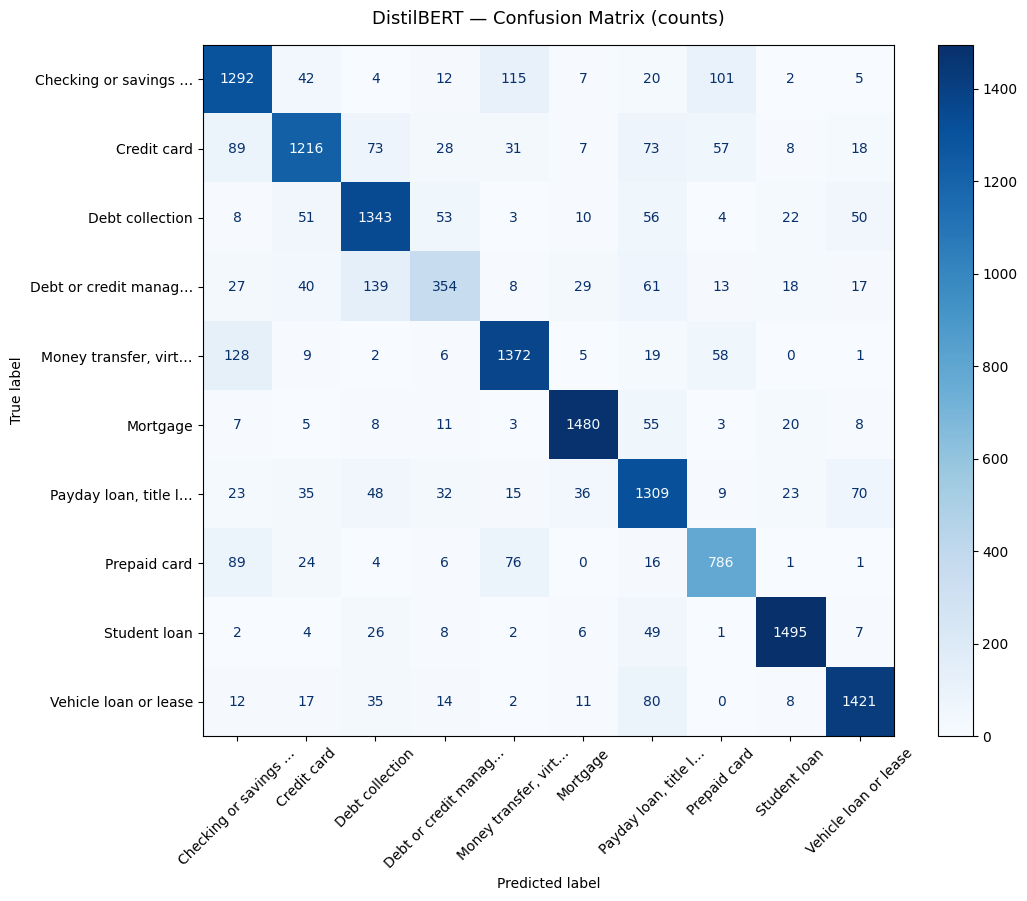

Saved: confusion_matrix_distilbert.png


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SHORT = [n if len(n) <= 22 else n[:20] + "…" for n in LABEL_NAMES]

cm = confusion_matrix(y_true, y_pred)          # raw counts, no normalization

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(cm, display_labels=SHORT).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, values_format="d", colorbar=True
)
ax.set_title("DistilBERT — Confusion Matrix (counts)", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("confusion_matrix_distilbert.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: confusion_matrix_distilbert.png")

## Step 10 — Save results and download

Saves everything needed for the report and the ML-vs-DL comparison table.

In [14]:
with open("distilbert_results.txt", "w") as f:
    f.write("DistilBERT — Consumer Complaint Classification\n")
    f.write("=" * 55 + "\n\n")
    f.write(f"Model            : {MODEL_NAME}\n")
    f.write(f"Training set     : {len(train_df)} rows")
    f.write(f"Test set         : {len(test_df)} rows (full shared test set)\n")
    f.write(f"Max token length : {MAX_LENGTH}\n")
    f.write(f"Epochs           : {training_args.num_train_epochs}\n\n")
    f.write(f"Macro F1    : {macro_f1:.4f}\n")
    f.write(f"Weighted F1 : {weighted_f1:.4f}\n")
    f.write(f"Accuracy    : {accuracy:.4f}\n\n")
    f.write("Per-class report:\n")
    f.write(report)

print(open("distilbert_results.txt").read())

from google.colab import files
files.download("distilbert_results.txt")
files.download("confusion_matrix_distilbert.png")

DistilBERT — Consumer Complaint Classification

Model            : distilbert-base-uncased
Training set     : 58036 rowsTest set         : 14509 rows (full shared test set)
Max token length : 256
Epochs           : 3

Macro F1    : 0.8140
Weighted F1 : 0.8304
Accuracy    : 0.8318

Per-class report:
                                                         precision    recall  f1-score   support

                            Checking or savings account     0.7704    0.8075    0.7885      1600
                                            Credit card     0.8427    0.7600    0.7992      1600
                                        Debt collection     0.7985    0.8394    0.8184      1600
                              Debt or credit management     0.6756    0.5014    0.5756       706
     Money transfer, virtual currency, or money service     0.8433    0.8575    0.8503      1600
                                               Mortgage     0.9302    0.9250    0.9276      1600
Payday loan, title l

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>